In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
X_train = [
    "good not bad",
    "really good not bad",
    "movie good not bad",
    "food good not bad",

    "bad not good",
    "really bad not good",
    "movie bad not good",
    "food bad not good"
]

y_train = [
    1, 1, 1, 1,
    0, 0, 0, 0
]

X_test = [
    "service good not bad",
    "product good not bad",
    "service bad not good",
    "product bad not good"
]

y_test = [1, 1, 0, 0]
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 4


In [3]:
training_dataframe = pd.DataFrame({
    "Text": X_train,
    "Label": y_train
})

testing_dataframe = pd.DataFrame({
    "Text": X_test,
    "Actual Label": y_test
})

print("Training Dataset:")
display(training_dataframe)

print("Testing Dataset:")
display(testing_dataframe)

Training Dataset:


,Text,Label
0,good not bad,1
1,really good not bad,1
2,movie good not bad,1
3,food good not bad,1
4,bad not good,0
5,really bad not good,0
6,movie bad not good,0
7,food bad not good,0


Testing Dataset:


,Text,Actual Label
0,service good not bad,1
1,product good not bad,1
2,service bad not good,0
3,product bad not good,0


In [4]:
unigram_vectorizer = CountVectorizer(
    ngram_range=(1, 1)
)

X_train_unigram = unigram_vectorizer.fit_transform(X_train)
X_test_unigram = unigram_vectorizer.transform(X_test)

unigram_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

unigram_model.fit(X_train_unigram, y_train)

unigram_predictions = unigram_model.predict(
    X_test_unigram
)

unigram_accuracy = accuracy_score(
    y_test,
    unigram_predictions
)

print("Unigram features:")
print(unigram_vectorizer.get_feature_names_out())

print("\nNumber of features:", X_train_unigram.shape[1])
print("Actual labels:   ", y_test)
print("Predicted labels:", unigram_predictions.tolist())
print(f"Accuracy: {unigram_accuracy:.2f}")

Unigram features:
['bad' 'food' 'good' 'movie' 'not' 'really']

Number of features: 6
Actual labels:    [1, 1, 0, 0]
Predicted labels: [0, 0, 0, 0]
Accuracy: 0.50


In [5]:
unigram_confusion_matrix = confusion_matrix(
    y_test,
    unigram_predictions
)

print("Unigram-only Confusion Matrix:")
print(unigram_confusion_matrix)

Unigram-only Confusion Matrix:
[[2 0]
 [2 0]]


In [6]:
ngram_vectorizer = CountVectorizer(
    ngram_range=(1, 2)
)

X_train_ngram = ngram_vectorizer.fit_transform(X_train)
X_test_ngram = ngram_vectorizer.transform(X_test)

ngram_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

ngram_model.fit(X_train_ngram, y_train)

ngram_predictions = ngram_model.predict(
    X_test_ngram
)

ngram_accuracy = accuracy_score(
    y_test,
    ngram_predictions
)

print("Unigram + Bigram features:")
print(ngram_vectorizer.get_feature_names_out())

print("\nNumber of features:", X_train_ngram.shape[1])
print("Actual labels:   ", y_test)
print("Predicted labels:", ngram_predictions.tolist())
print(f"Accuracy: {ngram_accuracy:.2f}")

Unigram + Bigram features:
['bad' 'bad not' 'food' 'food bad' 'food good' 'good' 'good not' 'movie'
 'movie bad' 'movie good' 'not' 'not bad' 'not good' 'really' 'really bad'
 'really good']

Number of features: 16
Actual labels:    [1, 1, 0, 0]
Predicted labels: [1, 1, 0, 0]
Accuracy: 1.00


In [7]:
ngram_confusion_matrix = confusion_matrix(
    y_test,
    ngram_predictions
)

print("Unigram + Bigram Confusion Matrix:")
print(ngram_confusion_matrix)

Unigram + Bigram Confusion Matrix:
[[2 0]
 [0 2]]


In [8]:
comparison_dataframe = pd.DataFrame({
    "Model": [
        "Unigram-only",
        "Unigram + Bigram"
    ],
    "N-gram Range": [
        "(1, 1)",
        "(1, 2)"
    ],
    "Number of Features": [
        X_train_unigram.shape[1],
        X_train_ngram.shape[1]
    ],
    "Accuracy": [
        unigram_accuracy,
        ngram_accuracy
    ]
})

display(comparison_dataframe)

,Model,N-gram Range,Number of Features,Accuracy
0,Unigram-only,"(1, 1)",6,0.5
1,Unigram + Bigram,"(1, 2)",16,1.0


In [9]:
sample_sentences = [
    "good not bad",
    "bad not good"
]

sample_unigram_vectors = unigram_vectorizer.transform(
    sample_sentences
).toarray()

sample_unigram_dataframe = pd.DataFrame(
    sample_unigram_vectors,
    columns=unigram_vectorizer.get_feature_names_out(),
    index=sample_sentences
)

display(sample_unigram_dataframe)

,bad,food,good,movie,not,really
good not bad,1,0,1,0,1,0
bad not good,1,0,1,0,1,0


In [10]:
sample_ngram_vectors = ngram_vectorizer.transform(
    sample_sentences
).toarray()

sample_ngram_dataframe = pd.DataFrame(
    sample_ngram_vectors,
    columns=ngram_vectorizer.get_feature_names_out(),
    index=sample_sentences
)

# যেসব feature অন্তত একবার উপস্থিত, শুধু সেগুলো দেখানো
used_features = (
    sample_ngram_dataframe.sum(axis=0) > 0
)

display(
    sample_ngram_dataframe.loc[:, used_features]
)

,bad,bad not,good,good not,not,not bad,not good
good not bad,1,0,1,1,1,1,0
bad not good,1,1,1,0,1,0,1


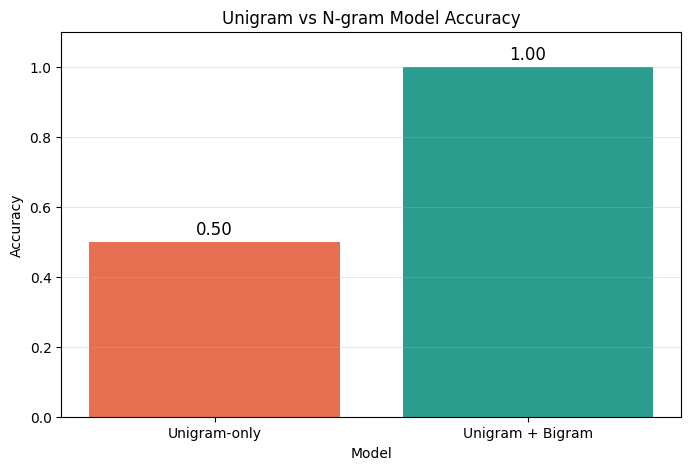

In [11]:
model_names = [
    "Unigram-only",
    "Unigram + Bigram"
]

accuracy_values = [
    unigram_accuracy,
    ngram_accuracy
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_names,
    accuracy_values,
    color=["#e76f51", "#2a9d8f"]
)

for bar, accuracy in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{accuracy:.2f}",
        ha="center",
        fontsize=12
    )

plt.title("Unigram vs N-gram Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.10)
plt.grid(axis="y", alpha=0.3)
plt.show()